In [1]:
# ==========================================================
# Week 5 - Step 1A
# Load Feature Matrix and Target Variable
# ==========================================================

import joblib

# Load processed features created in Week 3
X = joblib.load("../data/processed/X_features.pkl")

# Load target variable
y = joblib.load("../data/processed/y_target.pkl")

In [2]:
# ==========================================================
# Recreate Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

# IMPORTANT:
# Use the exact same random_state as Week 4
# so that the train and test sets remain identical.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [3]:
# ==========================================================
# Load Saved Random Forest Model
# ==========================================================

rf_model = joblib.load("../models/random_forest_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [4]:
# ----------------------------------------------------------
# Generate predictions using the loaded model
# ----------------------------------------------------------

y_pred_baseline = rf_model.predict(X_test)

In [5]:
# ----------------------------------------------------------
# Calculate baseline evaluation metrics
# ----------------------------------------------------------

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_mse = mean_squared_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("=" * 50)
print("Baseline Random Forest Performance")
print("=" * 50)

print(f"MAE  : {baseline_mae:.4f}")
print(f"MSE  : {baseline_mse:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline Random Forest Performance
MAE  : 0.4615
MSE  : 0.3873
RMSE : 0.6223
R²   : 0.5914


In [6]:
# ==========================================================
# Week 5 - Step 2
# Hyperparameter Tuning
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [7]:
# ----------------------------------------------------------
# Parameter search space
#
# These are the values RandomizedSearchCV will sample from.
# ----------------------------------------------------------

param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [10, 20, 30, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]
}

In [8]:
# ----------------------------------------------------------
# Base model
# ----------------------------------------------------------

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [9]:
# ----------------------------------------------------------
# RandomizedSearchCV
#
# n_iter = Number of random parameter combinations to test.
# cv = 5-fold cross-validation.
# scoring = R² because this is a regression task.
# ----------------------------------------------------------

random_search = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_grid,

    n_iter=20,

    cv=5,

    scoring="r2",

    verbose=2,

    random_state=42,

    n_jobs=-1
)

In [10]:
# ----------------------------------------------------------
# Start hyperparameter search
# ----------------------------------------------------------

random_search.fit(X_train, y_train)

print("✅ Hyperparameter tuning completed!")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Hyperparameter tuning completed!


In [11]:
print("Best Parameters:\n")

print(random_search.best_params_)

Best Parameters:

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [12]:
print("Best Cross Validation R² Score:")

print(random_search.best_score_)

Best Cross Validation R² Score:
0.604418755978183


In [13]:
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
0.604418755978183


In [14]:
# ==========================================================
# Week 5 - Step 3
# Retrieve the Best Random Forest Model
# ==========================================================

# Get the best-performing model found during tuning
best_rf_model = random_search.best_estimator_

print("✅ Best Random Forest model retrieved!")

✅ Best Random Forest model retrieved!


In [15]:
# ----------------------------------------------------------
# Predict AI Exposure Scores using the optimized model
# ----------------------------------------------------------

y_pred_optimized = best_rf_model.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

optimized_mae = mean_absolute_error(y_test, y_pred_optimized)
optimized_mse = mean_squared_error(y_test, y_pred_optimized)
optimized_rmse = np.sqrt(optimized_mse)
optimized_r2 = r2_score(y_test, y_pred_optimized)

print("=" * 50)
print("Optimized Random Forest Performance")
print("=" * 50)

print(f"MAE  : {optimized_mae:.4f}")
print(f"MSE  : {optimized_mse:.4f}")
print(f"RMSE : {optimized_rmse:.4f}")
print(f"R²   : {optimized_r2:.4f}")

Optimized Random Forest Performance
MAE  : 0.4712
MSE  : 0.3555
RMSE : 0.5962
R²   : 0.6249


In [17]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Optimized Random Forest"
    ],
    "MAE": [
        baseline_mae,
        optimized_mae
    ],
    "RMSE": [
        baseline_rmse,
        optimized_rmse
    ],
    "R² Score": [
        baseline_r2,
        optimized_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Baseline Random Forest,0.461468,0.622326,0.591402
1,Optimized Random Forest,0.471220,0.596244,0.624935


In [18]:
import joblib

joblib.dump(best_rf_model, "../models/final_random_forest_model.pkl")

print("✅ Optimized model saved successfully!")

✅ Optimized model saved successfully!


In [19]:
# ==========================================================
# Week 5 - Step 4
# Load TF-IDF Vectorizer
# ==========================================================

import joblib

tfidf = joblib.load("../data/processed/tfidf_vectorizer.pkl")

In [20]:
# ----------------------------------------------------------
# Retrieve feature names learned by the TF-IDF vectorizer
# ----------------------------------------------------------

tfidf_features = list(tfidf.get_feature_names_out())

print("Number of TF-IDF Features:", len(tfidf_features))

Number of TF-IDF Features: 1000


In [21]:
# ----------------------------------------------------------
# Engineered features added after TF-IDF
# ----------------------------------------------------------

engineered_features = [
    "task_length",
    "word_count",
    "task_type_encoded",
    "complexity_score"
]

all_features = tfidf_features + engineered_features

print("Total Features:", len(all_features))

Total Features: 1004


In [22]:
# ==========================================================
# Create Feature Importance DataFrame
# ==========================================================

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
1003,complexity_score,0.078952
961,using,0.021845
526,machines,0.011296
312,equipment,0.009586
635,parts,0.009014
777,research,0.008904
405,hand,0.008701
763,remove,0.008321
881,students,0.008271
248,develop,0.008150


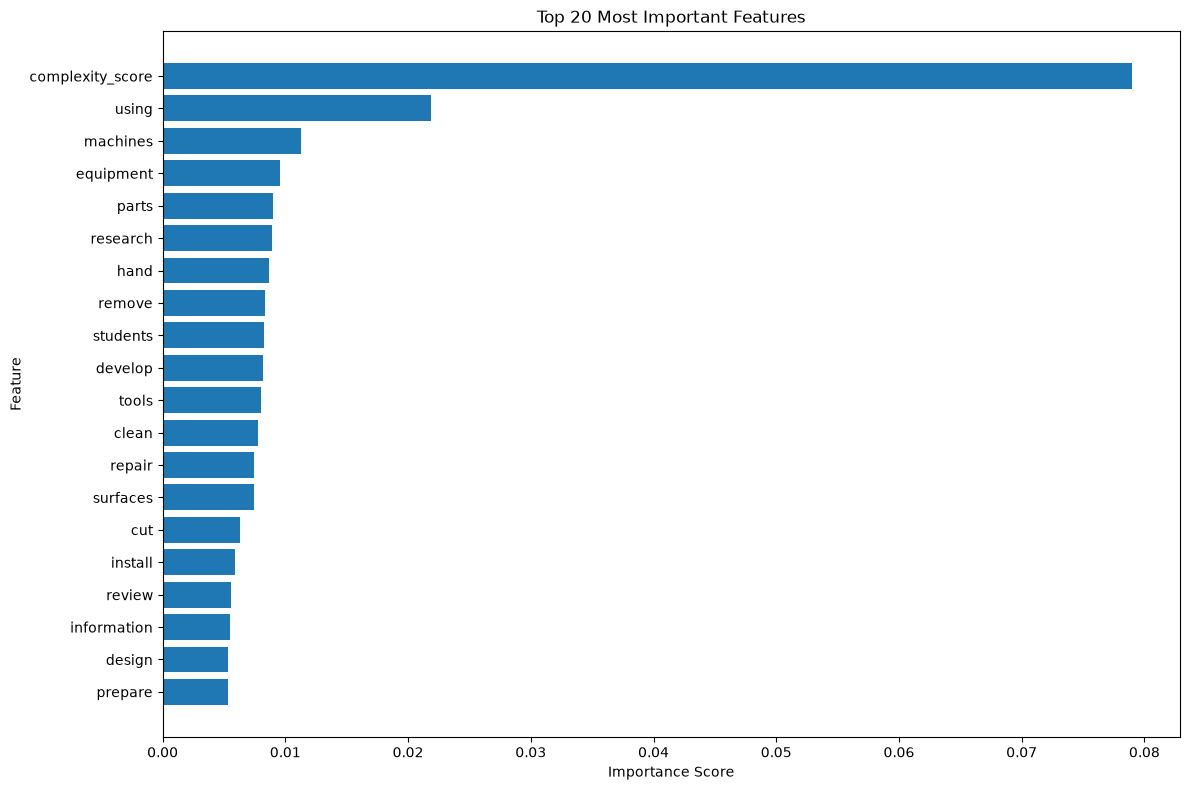

In [23]:
# ==========================================================
# Plot Feature Importance
# ==========================================================

import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [24]:
# ==========================================================
# Save Feature Importance
# ==========================================================

feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print(" Feature importance saved successfully!")

 Feature importance saved successfully!


In [25]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [26]:
# ==========================================================
# Week 5 - Step 5
# SHAP Explainability
# ==========================================================

# Tech Stack:
# SHAP -> Explain ML predictions

import shap

print("SHAP Version:", shap.__version__)

SHAP Version: 0.52.0


In [27]:
# ----------------------------------------------------------
# Create SHAP Tree Explainer
# ----------------------------------------------------------

explainer = shap.TreeExplainer(best_rf_model)

In [30]:
# Disable SHAP's strict additivity check
shap_values = explainer.shap_values(
    X_sample,
    check_additivity=False
)

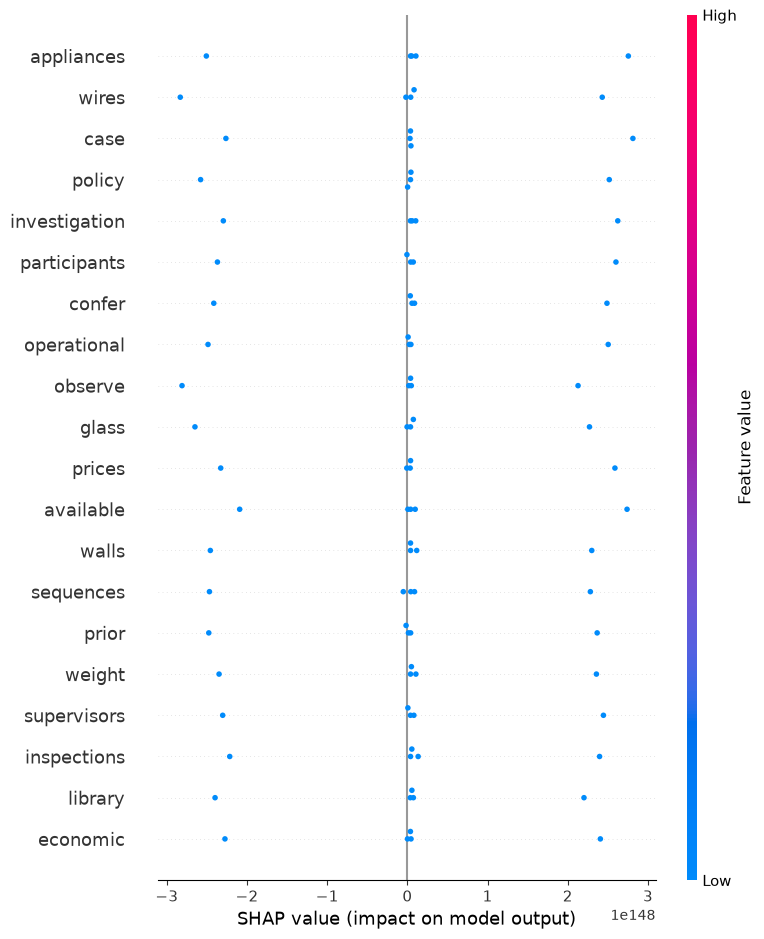

In [31]:
import shap

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=all_features
)

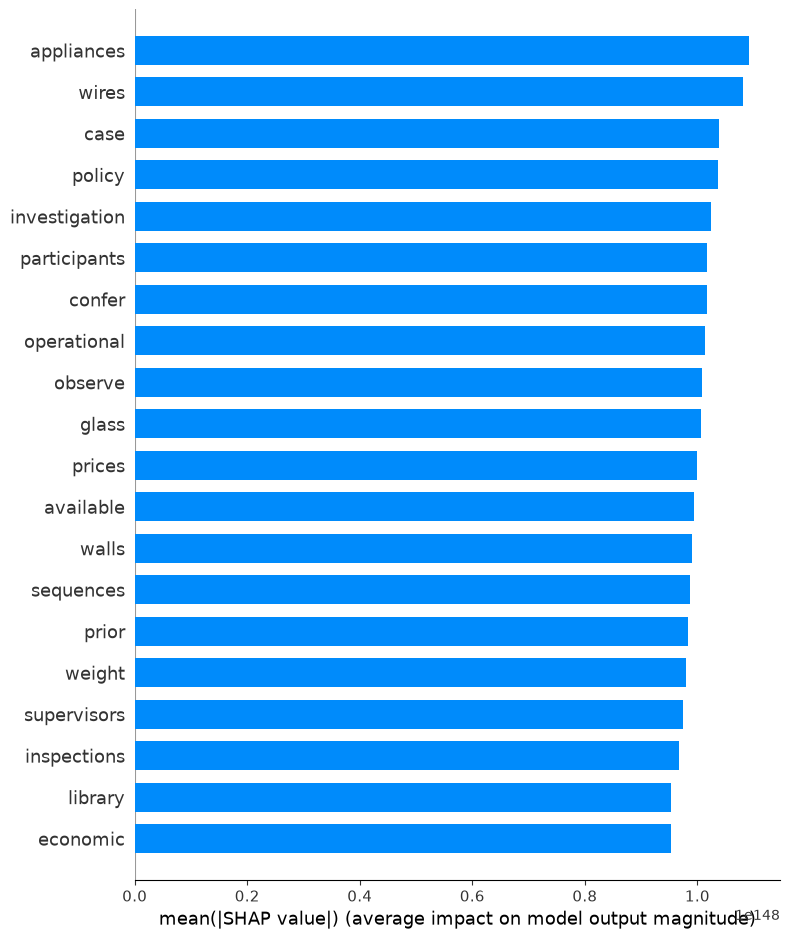

In [32]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=all_features,
    plot_type="bar"
)

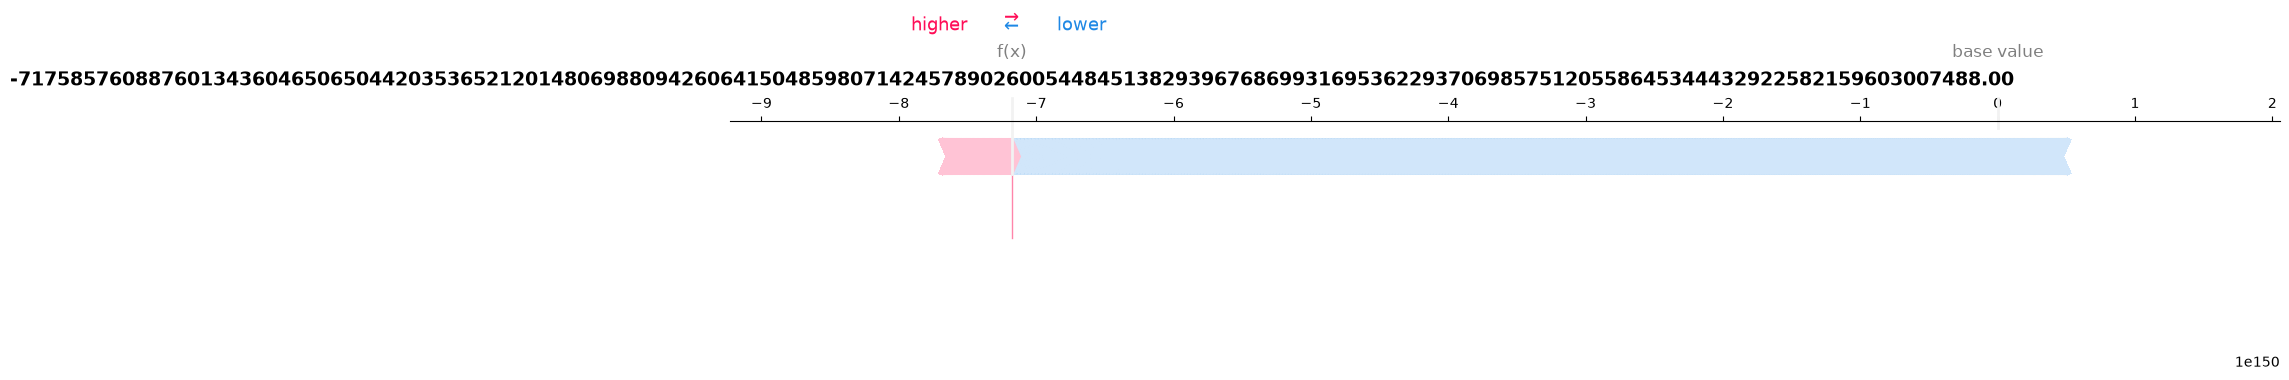

In [33]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    feature_names=all_features,
    matplotlib=True
)